<a href="https://colab.research.google.com/github/239y1a3931-sudo/Machain-Learning/blob/main/day14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

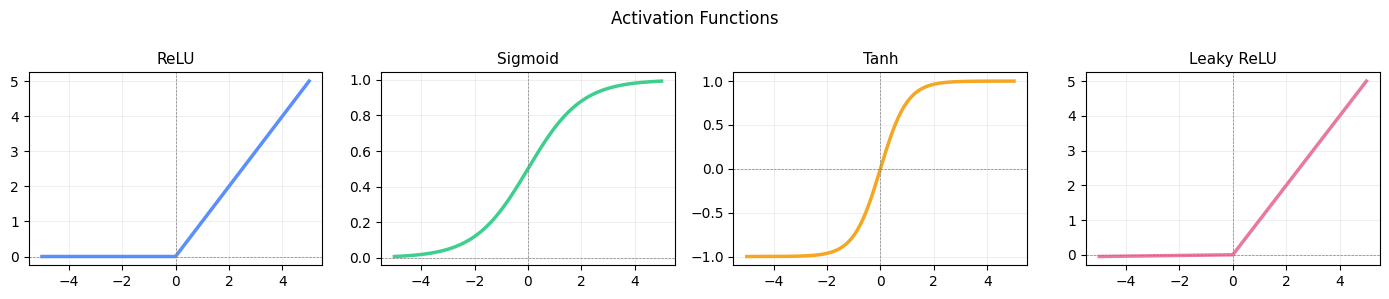

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 300)

relu = lambda x: np.maximum(0, x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh_fn = np.tanh
leaky = lambda x: np.where(x > 0, x, 0.01 * x)


fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fns = [relu, sigmoid, tanh_fn, leaky]
names = ['ReLU', 'Sigmoid', 'Tanh', 'Leaky ReLU']
cols = ['#5B8FF9','#3ECF8E','#F5A623','#E879A0']

for ax, fn, name, col in zip(axes, fns, names, cols):
  ax.plot(x, fn(x), color=col, linewidth=2.5)
  ax.axhline(0, color='gray', lw=0.5, ls='--')
  ax.axvline(0, color='gray', lw=0.5, ls='--')
  ax.set_title(name, fontsize=11)
  ax.grid(alpha=0.2)
  plt.suptitle('Activation Functions', fontsize=12)
plt.tight_layout();
plt.show()




In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ■■ Step 1: Load MNIST ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


# ■■ Step 2: Preprocess ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print(f'Train: {X_train.shape} Test: {X_test.shape}')



# ■■ Step 3: Build the model ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
model = keras.Sequential([
keras.Input(shape=(784,)),

layers.Dense(234, activation='relu'),
layers.Dropout(0.2),

layers.Dense(64, activation='relu'),
layers.Dropout(0.2),

layers.Dense(10, activation='softmax'),
])
model.summary()


Train: (60000, 784) Test: (10000, 784)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 234)            │       183,690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 234)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        15,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,380 (778.83 KB)

 Trainable params: 199,380 (778.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ■■ Step 4: Compile ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)



# ■■ Step 5: Callbacks — smart training ■■■■■■■■■■■■■■■■■■■■■■■
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


early_stop = EarlyStopping(monitor='val_loss', patience=5,
restore_best_weights=True, verbose=1)


# Halve learning rate if val_loss stalls for 3 epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
patience=3, min_lr=1e-6, verbose=1)




# ■■ Step 6: Train ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
history = model.fit(
X_train, y_train,
epochs=50,
batch_size=128,
validation_split=0.1,
callbacks=[early_stop, reduce_lr],
verbose=1
)


# history.history is a dict: {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8785 - loss: 0.4043 - val_accuracy: 0.9638 - val_loss: 0.1261 - learning_rate: 0.0010
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9489 - loss: 0.1692 - val_accuracy: 0.9712 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9630 - loss: 0.1225 - val_accuracy: 0.9793 - val_loss: 0.0760 - learning_rate: 0.0010
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9698 - loss: 0.1006 - val_accuracy: 0.9793 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9743 - loss: 0.0849 - val_accuracy: 0.9788 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9775 - loss: 0.0729 - val_accuracy: 0.9810 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9804 - loss: 0.062